# Sanity check
## Minimal verification that cascade produces non-nonsense trajectories

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ase.db import connect

from cascade.agents.db_orm import TrajectoryDB, DBTrajectoryFrame

In [2]:
db_url = 'postgresql://ase:pw@localhost:5432/cascade'
db = TrajectoryDB(db_url)
ase_db = connect(db_url)

In [3]:
runs = pd.DataFrame.from_records(db.list_runs())

In [4]:
runs.head()

,run_id,first_created,last_updated,n_trajectories,n_done_trajectories
0,2026.07.21-20:10:17-6390d2,2026-07-21 15:10:18.406663-05:00,2026-07-21 16:11:32.486066-05:00,4,4
1,2026.07.21-19:18:40-aa3ed9,2026-07-21 14:18:40.685733-05:00,2026-07-21 14:20:25.824762-05:00,4,4
2,2026.07.21-18:22:32-aa3ed9,2026-07-21 13:22:33.780604-05:00,2026-07-21 13:24:22.266808-05:00,4,2
3,2026.07.21-17:15:01-f0e007,2026-07-21 12:15:02.547131-05:00,2026-07-21 13:00:25.928051-05:00,4,0
4,2026.07.21-17:06:52-f0e007,2026-07-21 12:06:53.145719-05:00,2026-07-21 12:08:59.820871-05:00,4,0


In [5]:
runs.tail()

,run_id,first_created,last_updated,n_trajectories,n_done_trajectories
446,2025.10.31-18:21:40-451a69,2025-10-31 13:21:40.509101-05:00,2025-10-31 13:21:40.519187-05:00,2,0
447,2025.10.31-18:18:57-451a69,2025-10-31 13:18:57.625552-05:00,2025-10-31 13:18:57.635521-05:00,2,0
448,2025.10.31-18:18:16-451a69,2025-10-31 13:18:16.936863-05:00,2025-10-31 13:18:16.947114-05:00,2,0
449,2025.10.31-18:17:34-451a69,2025-10-31 13:17:34.834340-05:00,2025-10-31 13:17:34.844208-05:00,2,0
450,2025.10.31-18:17:13-451a69,2025-10-31 13:17:13.515018-05:00,2025-10-31 13:17:13.521163-05:00,2,0


In [6]:
#last_run_id = good_run = '2026.02.26-18:47:48-cbece8'

In [7]:
last_run_id = runs['run_id'][0]
db.list_run_summary(last_run_id)

{'run_id': '2026.07.21-20:10:17-6390d2',
 'n_trajectories': 4,
 'n_done': 4,
 'n_active': 0,
 'total_chunks': 16,
 'total_passed_chunks': 8,
 'total_failed_chunks': 8,
 'total_pending_chunks': 0,
 'total_training_frames': 40,
 'first_created': datetime.datetime(2026, 7, 21, 15, 10, 18, 406663, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))),
 'last_updated': datetime.datetime(2026, 7, 21, 16, 11, 32, 486066, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400)))}

In [8]:
traj_info = pd.DataFrame.from_records(db.list_trajectories_in_run(last_run_id))
traj_info

,traj_id,target_length,chunks_completed,status,created_at,updated_at
0,0,10,2,TrajectoryStatus.COMPLETED,2026-07-21 15:10:18.406663-05:00,2026-07-21 15:41:36.319974-05:00
1,1,10,2,TrajectoryStatus.COMPLETED,2026-07-21 15:10:18.528456-05:00,2026-07-21 15:12:22.352959-05:00
2,2,10,2,TrajectoryStatus.COMPLETED,2026-07-21 15:10:18.642928-05:00,2026-07-21 15:27:27.342400-05:00
3,3,10,2,TrajectoryStatus.COMPLETED,2026-07-21 15:10:18.760533-05:00,2026-07-21 16:11:32.486066-05:00


In [9]:
run_summary = db.list_trajectory_summary(last_run_id, 0)
run_summary

{'run_id': '2026.07.21-20:10:17-6390d2',
 'traj_id': 0,
 'target_length': 10,
 'chunks_completed': 2,
 'created_at': datetime.datetime(2026, 7, 21, 15, 10, 18, 406663, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))),
 'updated_at': datetime.datetime(2026, 7, 21, 15, 41, 36, 319974, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))),
 'n_chunk_attempts': 4,
 'n_unique_chunks': 2,
 'chunk_breakdown': {0: {'n_attempts': 3,
   'latest_status': 'PASSED',
   'latest_attempt_index': 2},
  1: {'n_attempts': 1, 'latest_status': 'PASSED', 'latest_attempt_index': 0}},
 'status_counts': {'PENDING': 0, 'PASSED': 2, 'FAILED': 2}}

In [10]:
chunks = pd.DataFrame.from_records(run_summary['chunk_breakdown'])
chunks

,0,1
n_attempts,3,1
latest_status,PASSED,PASSED
latest_attempt_index,2,0


In [11]:
traj_ids = traj_info['traj_id']

In [12]:
pd.set_option('display.max_rows', 100)

In [13]:
attempt_details = []
for traj_id in traj_ids:
    df = pd.DataFrame.from_records(db.list_trajectory_attempts(last_run_id, 0))
    df.insert(loc=0, column='traj_id', value=traj_id)
    attempt_details.append(df)
attempt_details = pd.concat(attempt_details)
attempt_details

,traj_id,chunk_id,attempt_index,n_frames,audit_status,model_version,created_at,updated_at
0,0,0,0,5,FAILED,0,2026-07-21 15:10:19.710258-05:00,2026-07-21 15:11:19.275893-05:00
1,0,0,1,5,FAILED,1,2026-07-21 15:23:43.683325-05:00,2026-07-21 15:25:30.867160-05:00
2,0,0,2,5,PASSED,2,2026-07-21 15:39:40.941460-05:00,2026-07-21 15:40:42.665598-05:00
3,0,1,0,5,PASSED,2,2026-07-21 15:40:42.917329-05:00,2026-07-21 15:41:36.319974-05:00
0,1,0,0,5,FAILED,0,2026-07-21 15:10:19.710258-05:00,2026-07-21 15:11:19.275893-05:00
1,1,0,1,5,FAILED,1,2026-07-21 15:23:43.683325-05:00,2026-07-21 15:25:30.867160-05:00
2,1,0,2,5,PASSED,2,2026-07-21 15:39:40.941460-05:00,2026-07-21 15:40:42.665598-05:00
3,1,1,0,5,PASSED,2,2026-07-21 15:40:42.917329-05:00,2026-07-21 15:41:36.319974-05:00
0,2,0,0,5,FAILED,0,2026-07-21 15:10:19.710258-05:00,2026-07-21 15:11:19.275893-05:00
1,2,0,1,5,FAILED,1,2026-07-21 15:23:43.683325-05:00,2026-07-21 15:25:30.867160-05:00


### These statuses are getting set at goofy times. the log says that these passed or failed, but theyre pending in the db...

In [14]:
passed_attempts = attempt_details.query('audit_status == "PASSED"')
passed_attempts.shape

(8, 8)

In [15]:
passed_attempts.groupby(['traj_id', 'chunk_id']).size().count()

8

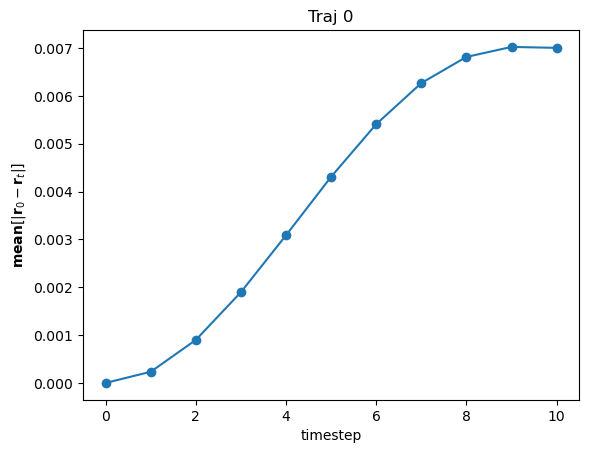

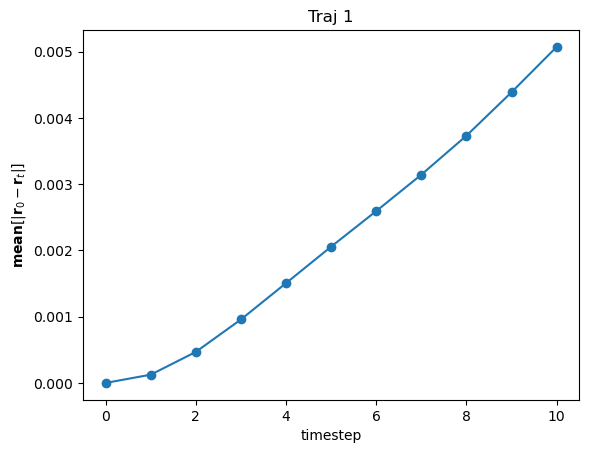

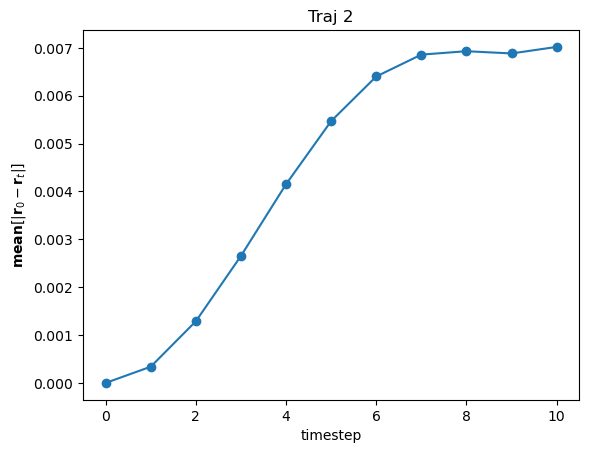

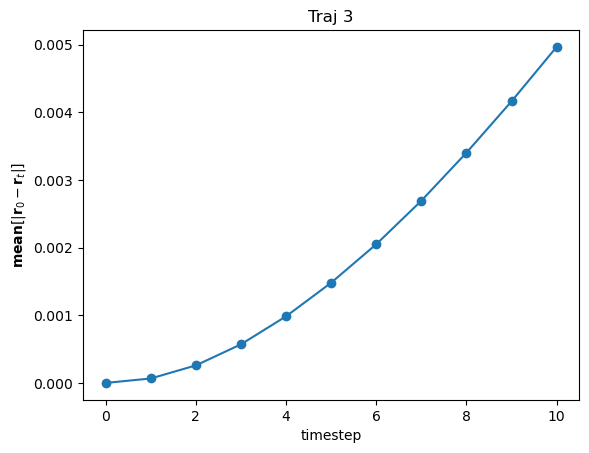

In [16]:
for traj_id in traj_ids: 
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    r0 = traj[0].get_positions()
    mad = np.zeros(len(traj))
    for i, a in enumerate(traj):
        mad[i] = np.mean(np.abs(a.get_positions() - r0))
    plt.plot(mad)
    t = np.arange(mad.shape[0])
    plt.scatter(t, mad)
    plt.xlabel('timestep')
    plt.ylabel('$\mathbf{mean} [|\mathbf{r}_0 - \mathbf{r}_t|]$')
    plt.title(f'Traj {traj_id}')
    plt.show()

In [17]:
for traj_id in traj_ids: 
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    print(f'traj: {traj_id}, n_frames: {len(traj)}')

traj: 0, n_frames: 11
traj: 1, n_frames: 11
traj: 2, n_frames: 11
traj: 3, n_frames: 11


In [18]:
db.count_chunk_events_by_type(last_run_id)

{'STARTED_LABELING': 8,
 'STARTED_LABELING_FRAME': 40,
 'FINISHED_LABELING_FRAME': 40,
 'FINISHED_LABELING': 8}

## plot training results

In [19]:
training_logs = db.get_training_logs(last_run_id)

In [20]:
training_logs.head()

,training_round,member_index,epoch,energy_mae_train,force_rmse_train,stress_rmse_train,total_loss_train,energy_mae_valid,force_rmse_valid,stress_rmse_valid,total_loss_valid,energy_mae_replay,force_rmse_replay,stress_rmse_replay,total_loss_replay
0,0,0,0,0.005234,0.094255,0.001795,0.064201,0.007746,0.118015,0.001808,0.069832,1.232672,0.559862,0.016502,1.325142
1,0,0,1,0.075435,0.593761,0.006034,1.483639,0.058497,0.367591,0.003443,0.653711,1.149419,0.490630,0.013579,1.216815
2,0,0,2,0.031183,0.241191,0.003551,0.296136,0.029884,0.251960,0.003149,0.317599,1.077186,0.266534,0.007529,0.739868
3,0,0,3,0.041464,0.254371,0.002516,0.343106,0.069545,0.082405,0.002094,0.036591,1.006792,0.162230,0.006276,0.539856
4,0,0,4,0.143113,0.519877,0.011012,1.213999,0.103944,0.251710,0.006110,0.323355,0.935494,0.128769,0.004575,0.457107


In [22]:
df_long = (
    training_logs
    .melt(id_vars=["training_round", "member_index", "epoch"],
          var_name="metric",
          value_name="value")
)

df_long[["quantity", "split"]] = (
    df_long["metric"].str.rsplit("_", n=1, expand=True)
)

In [23]:
df_long

,training_round,member_index,epoch,metric,value,quantity,split
0,0,0,0,energy_mae_train,0.005234,energy_mae,train
1,0,0,1,energy_mae_train,0.075435,energy_mae,train
2,0,0,2,energy_mae_train,0.031183,energy_mae,train
3,0,0,3,energy_mae_train,0.041464,energy_mae,train
4,0,0,4,energy_mae_train,0.143113,energy_mae,train
...,...,...,...,...,...,...,...
1195,4,1,5,total_loss_replay,0.495914,total_loss,replay
1196,4,1,6,total_loss_replay,0.432947,total_loss,replay
1197,4,1,7,total_loss_replay,0.676739,total_loss,replay
1198,4,1,8,total_loss_replay,0.580468,total_loss,replay


In [24]:
df = training_logs.copy()

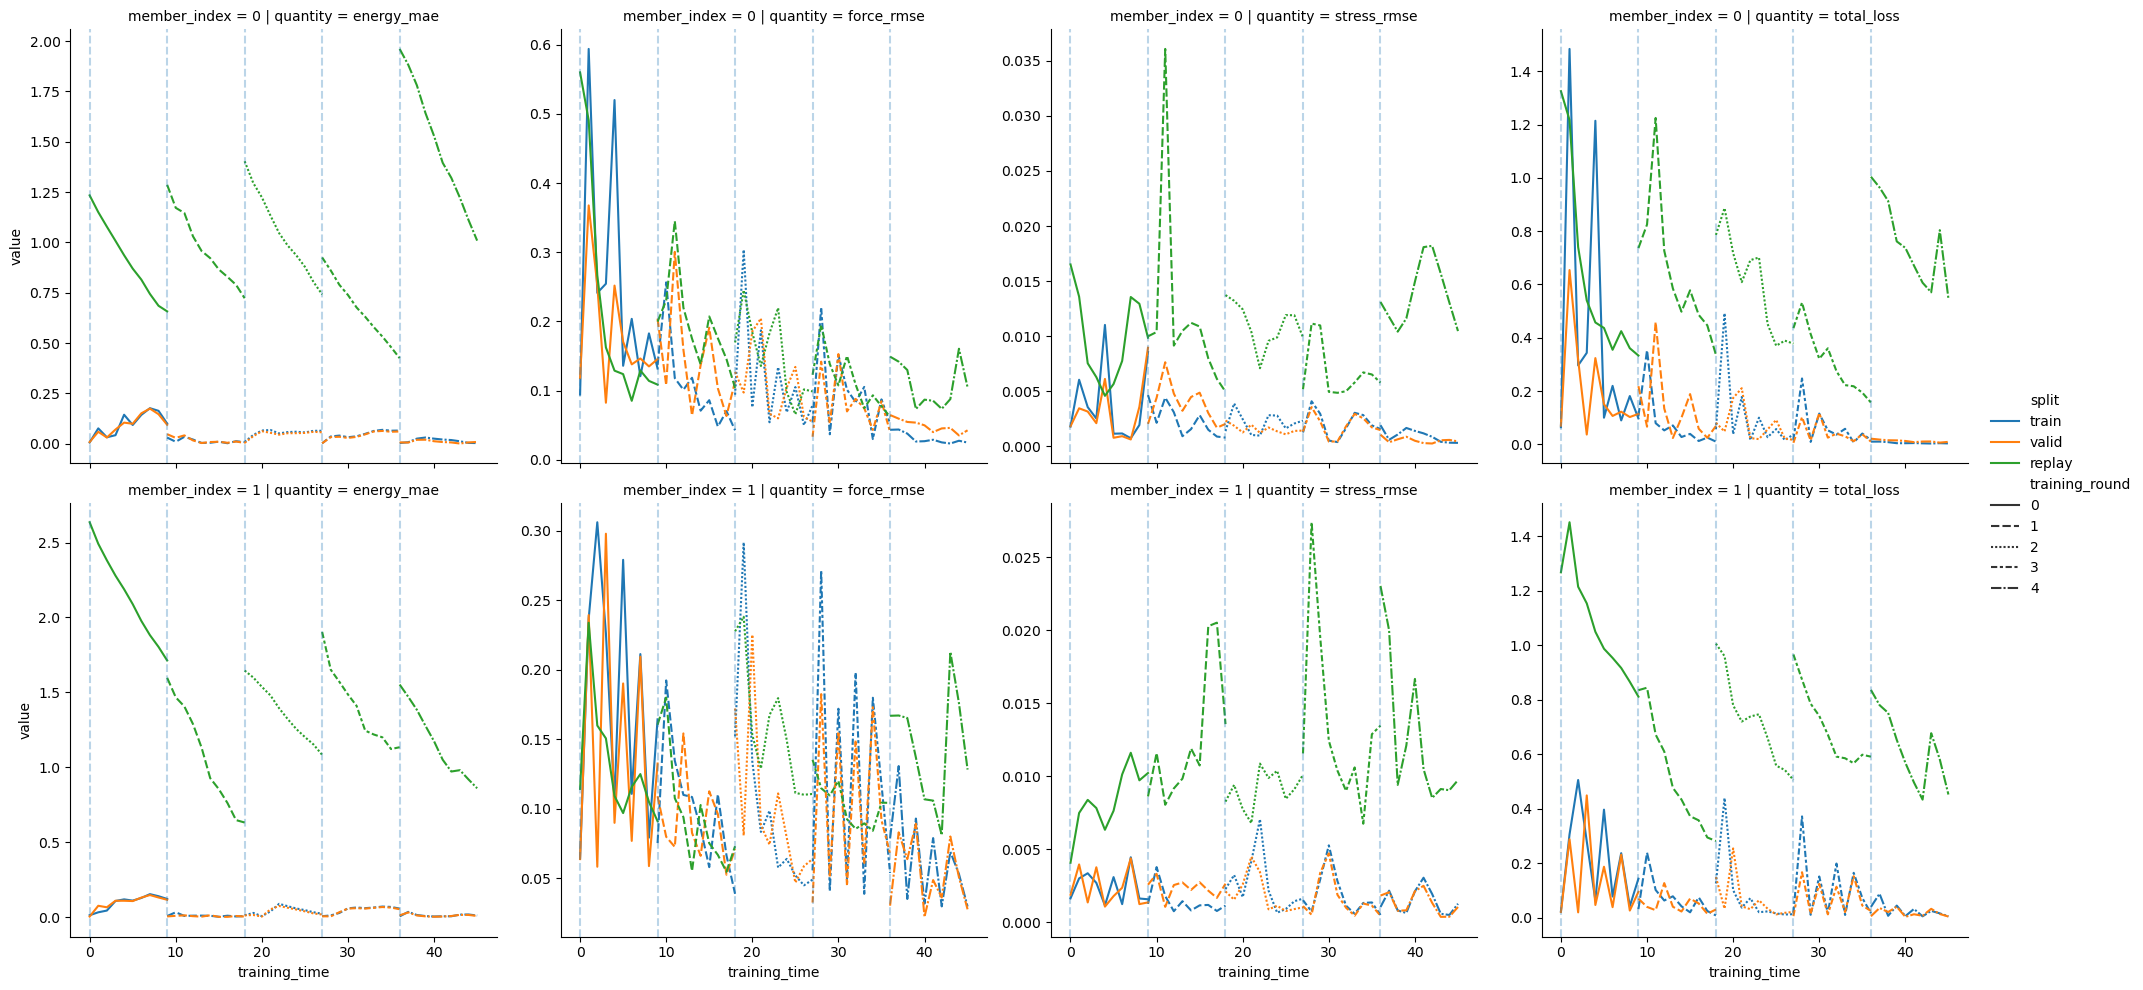

In [25]:
# --- sort ---
df = df.sort_values(["training_round", "member_index", "epoch"])

# --- build continuous training_time ---
round_max = df.groupby("training_round")["epoch"].max()
offsets = round_max.cumsum().shift(fill_value=0)

df["training_time"] = (
    df["epoch"] +
    df["training_round"].map(offsets)
)

# --- melt to long format ---
df_long = df.melt(
    id_vars=["training_round", "member_index", "epoch", "training_time"],
    var_name="metric",
    value_name="value"
)

# --- split metric into quantity + split ---
df_long[["quantity", "split"]] = (
    df_long["metric"].str.rsplit("_", n=1, expand=True)
)

# --- plot ---
g = sns.relplot(
    data=df_long,
    x="training_time",
    y="value",
    hue="split",                 # train vs valid
    style="training_round",      # distinguish rounds
    col="quantity",
    row="member_index",          # plot for each ensemble member
    kind="line",
    col_wrap=None,
    facet_kws={"sharey": False}
)

# --- add vertical round boundaries ---
for ax in g.axes.flatten():
    for boundary in offsets.values:
        ax.axvline(boundary, linestyle="--", alpha=0.3)

plt.show()